# NGC4698: [S II] input comparison

Compare the [S II] maps from gaussian-hermite 7000 and gaussian 8900. The histogram uses pixels with usable ratios in **both** inputs. A paired ratio map follows it. Three separate paired figures then show `n_e`, quality, and `n_e,all`, with gaussian-hermite 7000 on the left and gaussian 8900 on the right.

Both calculations use the source notebooks' PyNeb [S II] relation at 10,000 K on a 20–100,000 cm⁻³ grid. Finite positive line values are required, with no S/N selection. The primary maps are recorded per Angstrom and the corrected maps as integrated flux; their dimensionless ratios can be compared here. The `n_e,all` map assigns 20 cm⁻³ where `n_e` is unavailable within each input's joint finite footprint. It is a filled map, not a second set of measurements. No files are written by this notebook.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap, LogNorm
from matplotlib.patches import Patch
import numpy as np
import pyneb as pn
from astropy.io import fits
from astropy.wcs import WCS

ROOT = Path('/Users/Igniz/Desktop/ICRAR/NGC4698')
PRIMARY_6716 = ROOT / 'flux_map_SII6716_primary_gas_fit.fits'
PRIMARY_6731 = ROOT / 'flux_map_SII6731_primary_gas_fit.fits'
CORRECTED = Path('/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8/NGC4698/NGC4698_gas_bin_maps_further.fits')
TE_K, NE_MIN, NE_MAX, N_GRID = 10_000.0, 20.0, 100_000.0, 4096
MIN_LINE_VALUE = 0.0  # Flux floor, not an S/N threshold.
for path in (PRIMARY_6716, PRIMARY_6731, CORRECTED):
    if not path.is_file():
        raise FileNotFoundError(path)

## Load and check both inputs

All four maps must have matching 2-D shapes and celestial WCS. Units must match within each doublet pair.

In [2]:
with fits.open(PRIMARY_6716, memmap=True) as hdul:
    p16, hp16 = np.asarray(hdul[0].data, dtype=float), hdul[0].header.copy()
with fits.open(PRIMARY_6731, memmap=True) as hdul:
    p31, hp31 = np.asarray(hdul[0].data, dtype=float), hdul[0].header.copy()
with fits.open(CORRECTED, memmap=True) as hdul:
    c16 = np.asarray(hdul['SII6716_FLUX_CORR'].data, dtype=float)
    c31 = np.asarray(hdul['SII6730_FLUX_CORR'].data, dtype=float)
    hc16 = hdul['SII6716_FLUX_CORR'].header.copy()
    hc31 = hdul['SII6730_FLUX_CORR'].header.copy()
inputs = {'gaussian-hermite 7000': (p16, p31, hp16, hp31),
          'gaussian 8900': (c16, c31, hc16, hc31)}
shape = p16.shape
if len(shape) != 2 or any(a.shape != shape or b.shape != shape
                          for a, b, _, _ in inputs.values()):
    raise ValueError('The four line maps must have the same 2-D shape')
ny, nx = shape
px, py = np.array([0, nx // 2, nx-1], float), np.array([0, ny // 2, ny-1], float)
wcs_list = [WCS(h).celestial for _, _, h1, h2 in inputs.values() for h in (h1, h2)]
ref_sky = wcs_list[0].pixel_to_world_values(px, py)
for w in wcs_list[1:]:
    sky = w.pixel_to_world_values(px, py)
    if not all(np.allclose(a, b, rtol=0, atol=1e-8) for a, b in zip(ref_sky, sky)):
        raise ValueError('Celestial WCS grids differ')
for name, (_, _, h1, h2) in inputs.items():
    if h1.get('BUNIT') != h2.get('BUNIT'):
        raise ValueError(f'{name}: line units differ')
    print(f'{name}: shape={shape}; BUNIT={h1.get("BUNIT")}')
plot_wcs = wcs_list[0]

gaussian-hermite 7000: shape=(1189, 608); BUNIT=10**-20 Angstrom-1 cm-2 erg s-1
gaussian 8900: shape=(1189, 608); BUNIT=1e-20 erg s-1 cm-2


## Histograms of the two observed [S II] ratios

Both distributions use the same matched pixels. Bin fractions use *all* matched pixels as the denominator, including ratios above the displayed range.

gaussian-hermite 7000: 351,946 matched pixels; 0 above plot range
gaussian 8900: 351,946 matched pixels; 1,542 above plot range


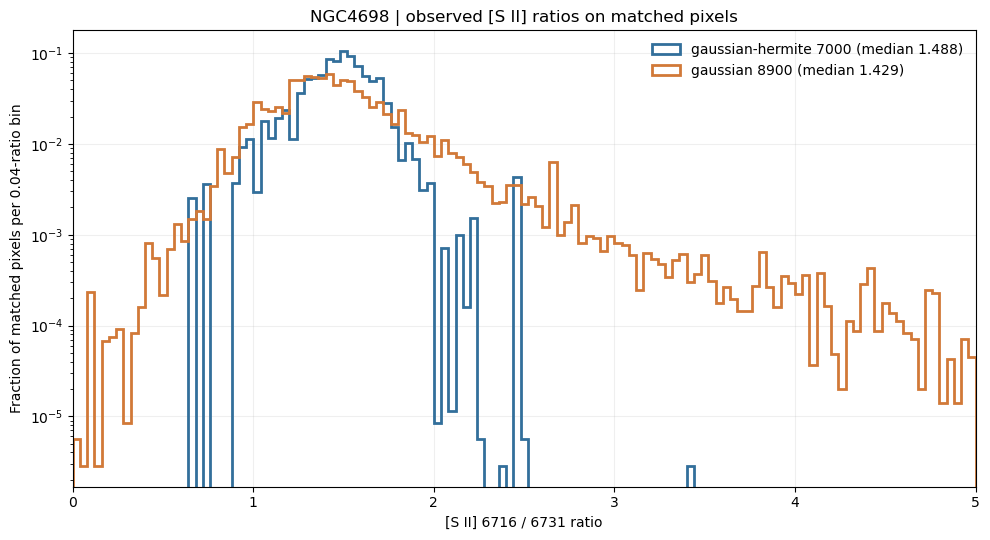

In [3]:
results = {}
for name, (f16, f31, _, _) in inputs.items():
    usable = np.isfinite(f16) & np.isfinite(f31) & (f16 > MIN_LINE_VALUE) & (f31 > MIN_LINE_VALUE)
    ratio = np.full(shape, np.nan)
    np.divide(f16, f31, out=ratio, where=usable)
    usable &= np.isfinite(ratio) & (ratio > 0)
    ratio[~usable] = np.nan
    results[name] = {'ratio':ratio, 'usable':usable,
                     'footprint':np.isfinite(f16) & np.isfinite(f31)}
matched = results['gaussian-hermite 7000']['usable'] & results['gaussian 8900']['usable']
if not matched.any():
    raise ValueError('No pixels have usable ratios in both inputs')
bins = np.linspace(0, 5, 126)
fig, ax = plt.subplots(figsize=(10, 5.5))
for name, color in [('gaussian-hermite 7000', '#326f9b'), ('gaussian 8900', '#d17938')]:
    values = results[name]['ratio'][matched]
    ax.hist(values, bins=bins, weights=np.full(values.size, 1 / values.size),
            histtype='step', linewidth=2, color=color,
            label=f'{name} (median {np.median(values):.3f})')
    print(f'{name}: {values.size:,} matched pixels; {(values > 5).sum():,} above plot range')
ax.set(xlim=(0, 5), yscale='log', xlabel='[S II] 6716 / 6731 ratio',
       ylabel='Fraction of matched pixels per 0.04-ratio bin',
       title='NGC4698 | observed [S II] ratios on matched pixels')
ax.grid(alpha=0.2)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## [S II] line ratio maps

The observed 6716/6731 ratio is shown for each input on its own usable pixels. Both panels use one color scale spanning the 1st to 99th percentiles of the combined finite ratios; clipping affects display only. Gray marks pixels without two finite positive line values.

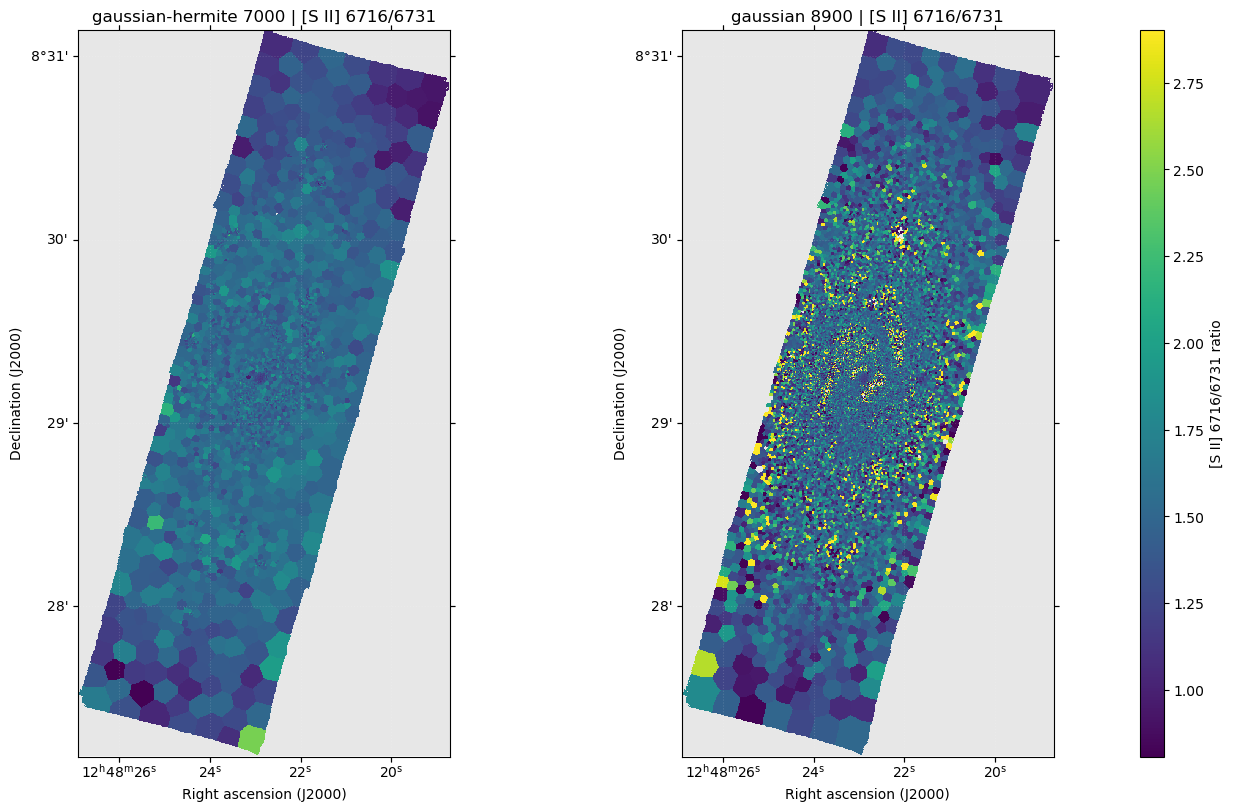

In [4]:
ratio_values = np.concatenate([r['ratio'][r['usable']] for r in results.values()])
ratio_vmin, ratio_vmax = np.percentile(ratio_values, [1, 99])
if not ratio_vmax > ratio_vmin:
    raise ValueError('The shared ratio display range is empty')
ratio_cmap = plt.get_cmap('viridis').copy()
ratio_cmap.set_bad('#e7e7e7')
fig = plt.figure(figsize=(13, 8), constrained_layout=True)
grid = fig.add_gridspec(1, 3, width_ratios=(1, 1, 0.045))
axes = [fig.add_subplot(grid[0, col], projection=plot_wcs) for col in range(2)]
for ax, (name, result) in zip(axes, results.items()):
    ax.imshow(np.ma.masked_invalid(result['ratio']), origin='lower',
              interpolation='nearest', cmap=ratio_cmap,
              vmin=ratio_vmin, vmax=ratio_vmax)
    ax.set_title(f'{name} | [S II] 6716/6731')
    ax.coords[0].set_axislabel('Right ascension (J2000)')
    ax.coords[1].set_axislabel('Declination (J2000)')
    ax.coords.grid(color='white', alpha=0.15, linestyle=':')
bar = fig.colorbar(axes[1].images[0], cax=fig.add_subplot(grid[0, 2]))
bar.set_label('[S II] 6716/6731 ratio')
plt.show()

### [S II] ratio maps with a fixed 0.6–1.4 color range

This companion figure shows the same ratios and usable pixels as the preceding map. Values outside 0.6–1.4 are clipped only in the color display; no data or quality categories are changed.

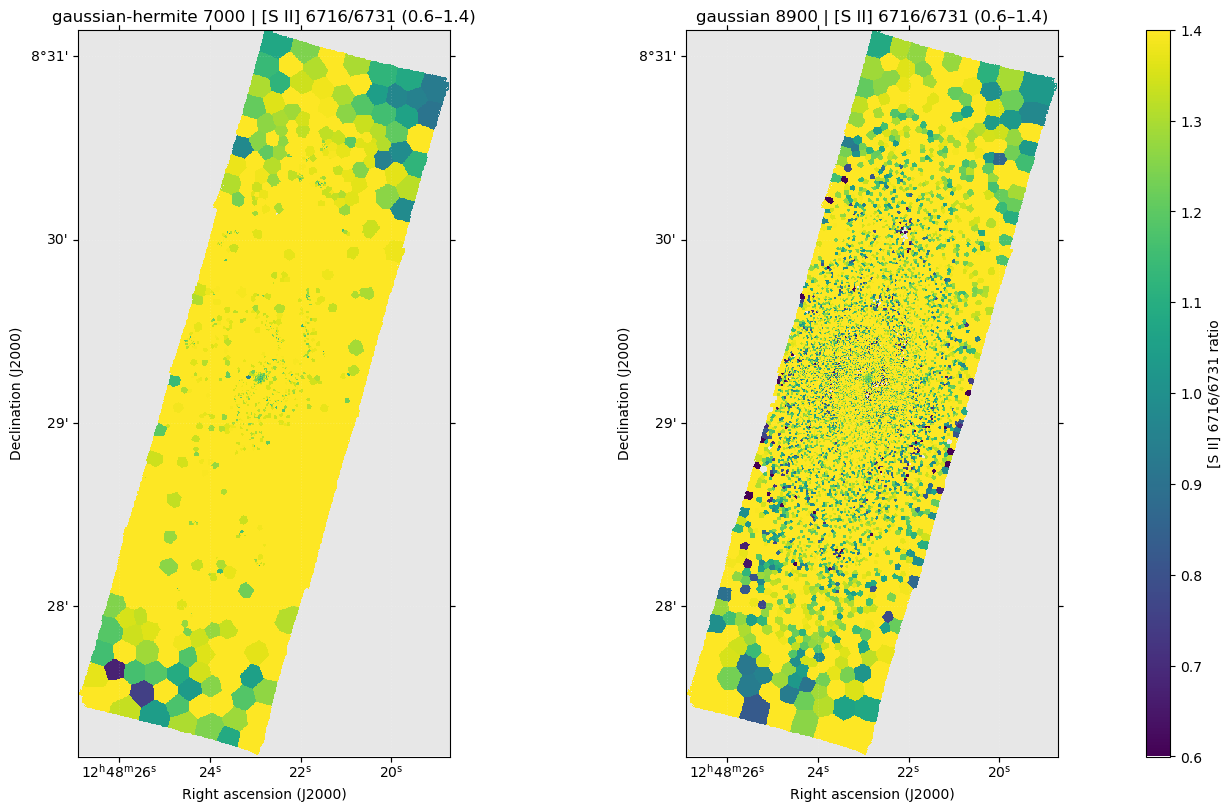

In [5]:
fig = plt.figure(figsize=(13, 8), constrained_layout=True)
grid = fig.add_gridspec(1, 3, width_ratios=(1, 1, 0.045))
axes = [fig.add_subplot(grid[0, col], projection=plot_wcs) for col in range(2)]
for ax, (name, result) in zip(axes, results.items()):
    ax.imshow(np.ma.masked_invalid(result['ratio']), origin='lower',
              interpolation='nearest', cmap=ratio_cmap,
              vmin=0.6, vmax=1.4)
    ax.set_title(f'{name} | [S II] 6716/6731 (0.6–1.4)')
    ax.coords[0].set_axislabel('Right ascension (J2000)')
    ax.coords[1].set_axislabel('Declination (J2000)')
    ax.coords.grid(color='white', alpha=0.15, linestyle=':')
bar = fig.colorbar(axes[1].images[0], cax=fig.add_subplot(grid[0, 2]))
bar.set_label('[S II] 6716/6731 ratio')
plt.show()

## Density and quality calculations

Quality codes: 0 unusable input; 1 in-grid measurement; 2 20 cm⁻³ floor between the grid edge and physical low-density limit; 3 above the physical ratio limit; 4 below the high-density grid ratio edge. Only codes 1 and 2 receive finite `n_e`. The joint finite flux footprint for `n_e,all` can include nonpositive line values.

In [6]:
sii = pn.Atom('S', 2)
density_grid = np.geomspace(NE_MIN, NE_MAX, N_GRID)
theory = (np.asarray(sii.getEmissivity(tem=TE_K, den=density_grid, wave=6716), float)
          / np.asarray(sii.getEmissivity(tem=TE_K, den=density_grid, wave=6731), float))
if theory.shape != density_grid.shape or not np.isfinite(theory).all() or not (np.diff(theory) < 0).all():
    raise ValueError('Invalid PyNeb ratio grid')
r20, r100000 = float(theory[0]), float(theory[-1])
low_limit = float(sii.getLowDensRatio(wave1=6716, wave2=6731, tem=TE_K))
if low_limit <= r20:
    raise ValueError('Low-density ratio limit must exceed the grid edge')
print('PyNeb atomic files:', sii.atomFile, sii.collFile)
print('Ratio edges (100000, 20, physical low density):', r100000, r20, low_limit)
qc_labels = {0:'unusable input', 1:'in-grid density', 2:'20 cm^-3 floor',
             3:'above physical ratio limit', 4:'below high-density grid edge'}
for name, result in results.items():
    ratio, usable = result['ratio'], result['usable']
    measured = usable & (ratio >= r100000) & (ratio <= r20)
    floor = usable & (ratio > r20) & (ratio <= low_limit)
    above = usable & (ratio > low_limit)
    high = usable & (ratio < r100000)
    qc = np.zeros(shape, np.uint8)
    qc[measured], qc[floor], qc[above], qc[high] = 1, 2, 3, 4
    ne = np.full(shape, np.nan)
    ne[measured] = np.interp(ratio[measured], theory[::-1], density_grid[::-1])
    ne[floor] = NE_MIN
    footprint = result['footprint']
    ne_all = np.where(footprint, np.where(np.isfinite(ne), ne, NE_MIN), np.nan)
    if not np.array_equal(np.isfinite(ne_all), footprint) or np.isfinite(ne[above | high]).any():
        raise ValueError(f'{name}: density/quality inconsistency')
    result.update(qc=qc, ne=ne, ne_all=ne_all, measured=measured)
    print(f'\n{name}: ' + ', '.join(f'QC{k}={np.count_nonzero(qc == k):,}' for k in qc_labels))
    print(f'finite n_e={np.isfinite(ne).sum():,}; n_e,all fallback={(footprint & ~np.isfinite(ne)).sum():,}')

PyNeb atomic files: s_ii_atom_RGJ19.dat s_ii_coll_TZ10.dat
Ratio edges (100000, 20, physical low density): 0.44744396679934006 1.4323317191084541 1.4549437994634162

gaussian-hermite 7000: QC0=369,293, QC1=138,292, QC2=15,625, QC3=199,702, QC4=0
finite n_e=153,917; n_e,all fallback=199,710

gaussian 8900: QC0=370,958, QC1=177,344, QC2=7,856, QC3=166,067, QC4=687
finite n_e=185,200; n_e,all fallback=167,350


## Side-by-side maps

Three separate figures compare the two inputs: `n_e`, quality, and `n_e,all`. Each density figure uses one shared logarithmic color scale across its two maps. Gray denotes missing density, and the quality figure uses one shared legend.

In [7]:
measured_values = np.concatenate([r['ne'][r['measured']] for r in results.values()])
if not measured_values.size:
    raise ValueError('Neither input has an in-grid density measurement')
vmax = max(1000.0, float(np.percentile(measured_values, 99)))
density_norm = LogNorm(vmin=NE_MIN, vmax=vmax)
density_cmap = plt.get_cmap('magma').copy()
density_cmap.set_bad('#e7e7e7')
qc_colors = ['#e7e7e7', '#3274a1', '#6ca968', '#dc8850', '#9c5b9f']
qc_cmap = ListedColormap(qc_colors)
qc_norm = BoundaryNorm(np.arange(-0.5, 5.5), qc_cmap.N)

def plot_pair(key, title, colorbar_label=None):
    is_quality = key == 'qc'
    fig = plt.figure(figsize=(13, 8), constrained_layout=True)
    if is_quality:
        grid = fig.add_gridspec(1, 2)
    else:
        grid = fig.add_gridspec(1, 3, width_ratios=(1, 1, 0.045))
    axes = [fig.add_subplot(grid[0, col], projection=plot_wcs) for col in range(2)]
    for ax, (name, result) in zip(axes, results.items()):
        data = result[key] if is_quality else np.ma.masked_invalid(result[key])
        ax.imshow(data, origin='lower', interpolation='nearest',
                  cmap=qc_cmap if is_quality else density_cmap,
                  norm=qc_norm if is_quality else density_norm)
        ax.set_title(f'{name} | {title}')
        ax.coords[0].set_axislabel('Right ascension (J2000)')
        ax.coords[1].set_axislabel('Declination (J2000)')
        ax.coords.grid(color='white', alpha=0.15, linestyle=':')
    if is_quality:
        handles = [Patch(facecolor=qc_colors[k], label=f'{k}: {qc_labels[k]}')
                   for k in qc_labels]
        fig.legend(handles=handles, loc='lower center', ncol=3,
                   bbox_to_anchor=(0.5, -0.12), frameon=False)
    else:
        bar = fig.colorbar(axes[1].images[0], cax=fig.add_subplot(grid[0, 2]))
        bar.set_label(colorbar_label + ' (log colour scale)')
    plt.show()

### Electron density `n_e`

Only in-grid densities and flagged 20 cm⁻³ floors are finite.

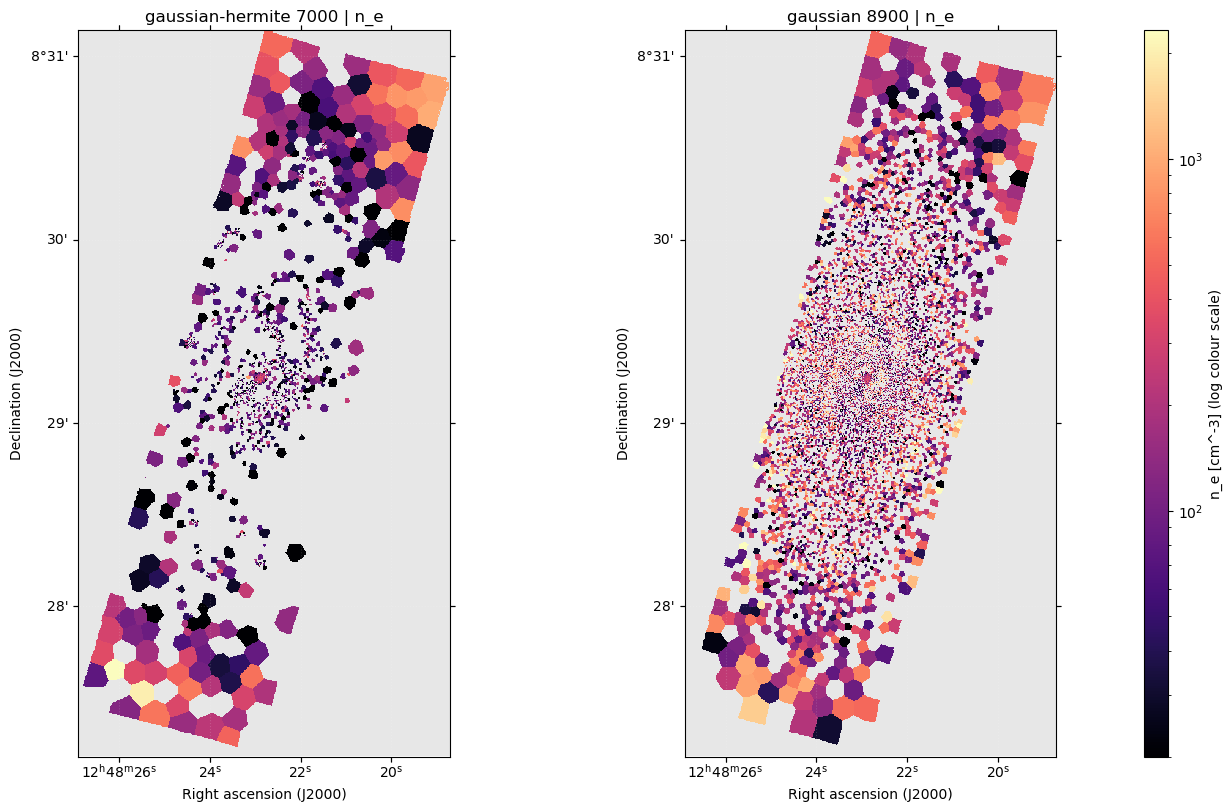

In [8]:
plot_pair('ne', 'n_e', 'n_e [cm^-3]')

### Density quality

Quality codes use the same definitions and colors for both inputs.

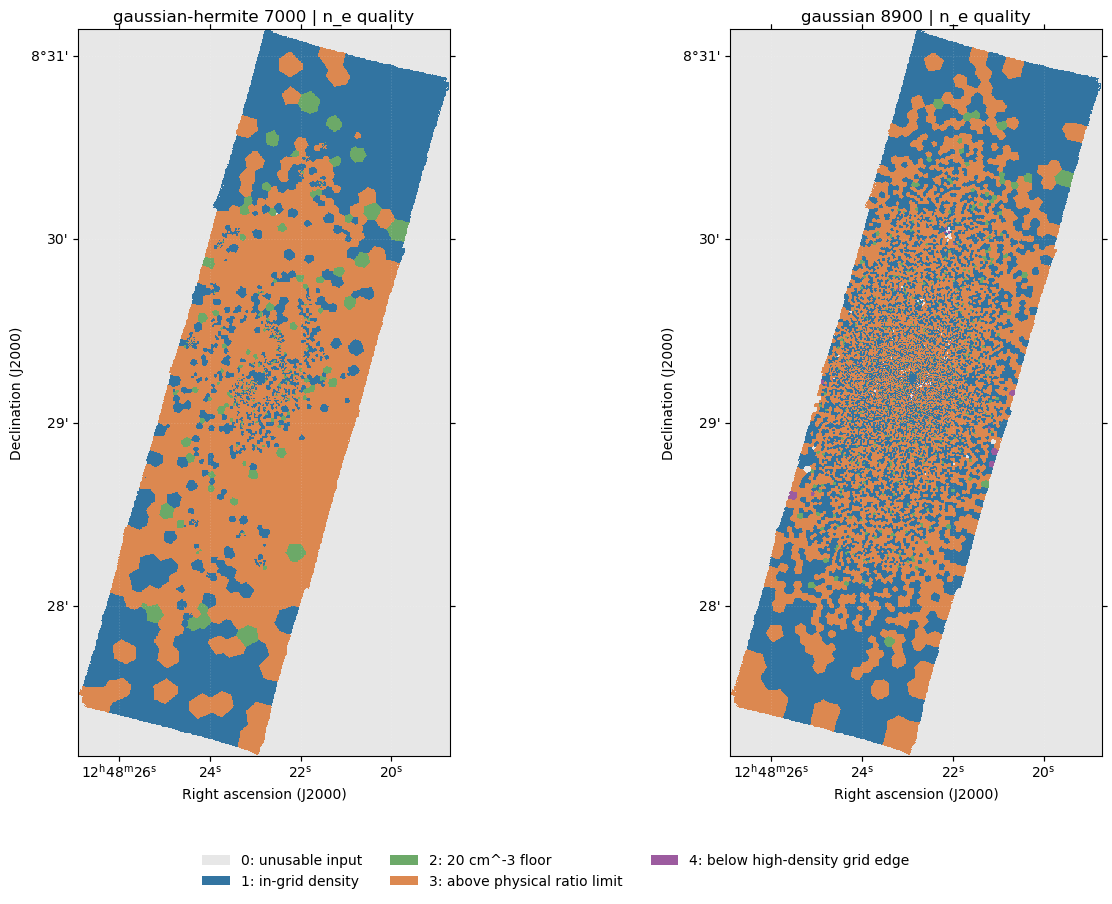

In [9]:
plot_pair('qc', 'n_e quality')

### Filled density `n_e,all`

The 20 cm⁻³ fallback within each joint finite flux footprint is an assigned value, not a measured density.

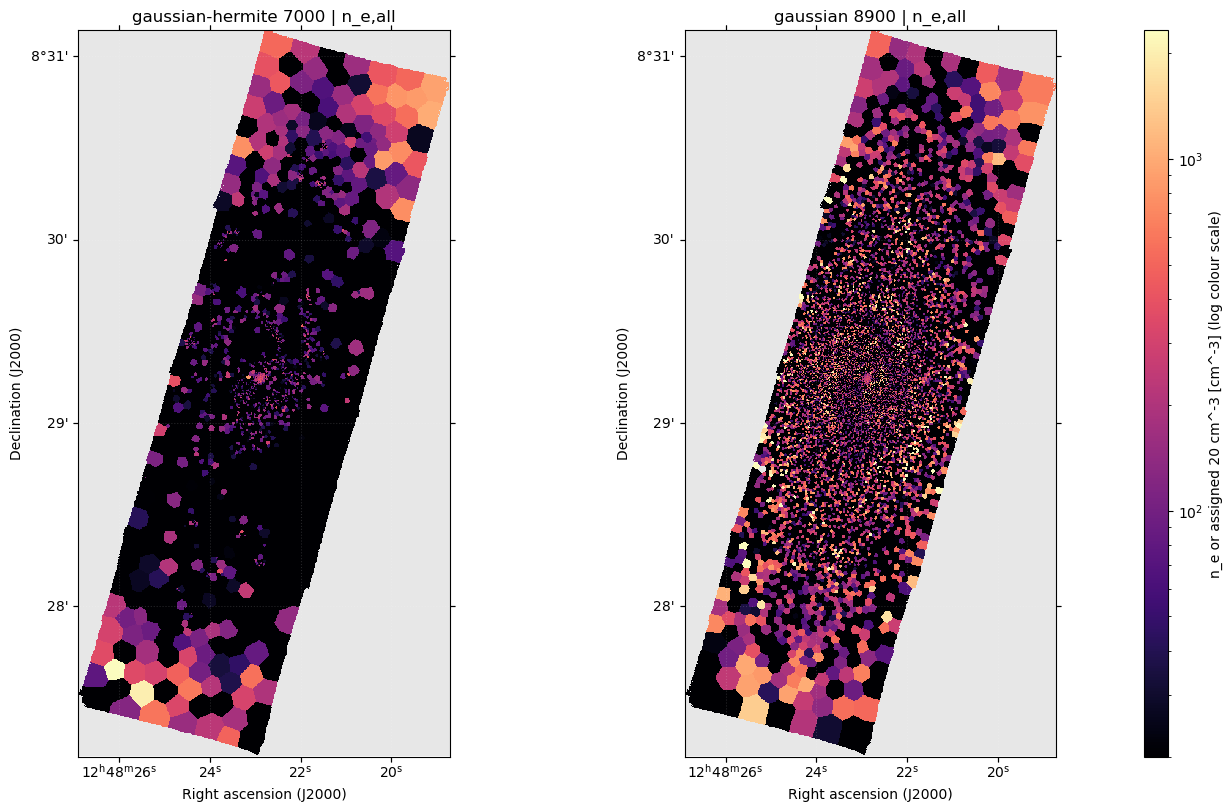

In [10]:
plot_pair('ne_all', 'n_e,all', 'n_e or assigned 20 cm^-3 [cm^-3]')